In [34]:
# 0. Setting

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df[df['DX'] == 'CN'].nsmallest(5, 'Hippocampus')

MCI PATIENTS DISTRIBUTION ANALYSIS

📊 MCI Patients Overview:
  Total MCI observations: 1,812
  Unique subjects: 387

📊 Data Statistics (after removing NaN):
  Valid observations: 1,812

  MMSE:
    Mean: 26.05 ± 3.62
    Median: 27.00
    Range: [0, 30]

  Normalized Hippocampus (% of ICV):
    Mean: 0.3998%
    Std:  0.0801%
    Median: 0.3914%
    Range: [0.1314%, 0.6614%]

Creating Visualizations...


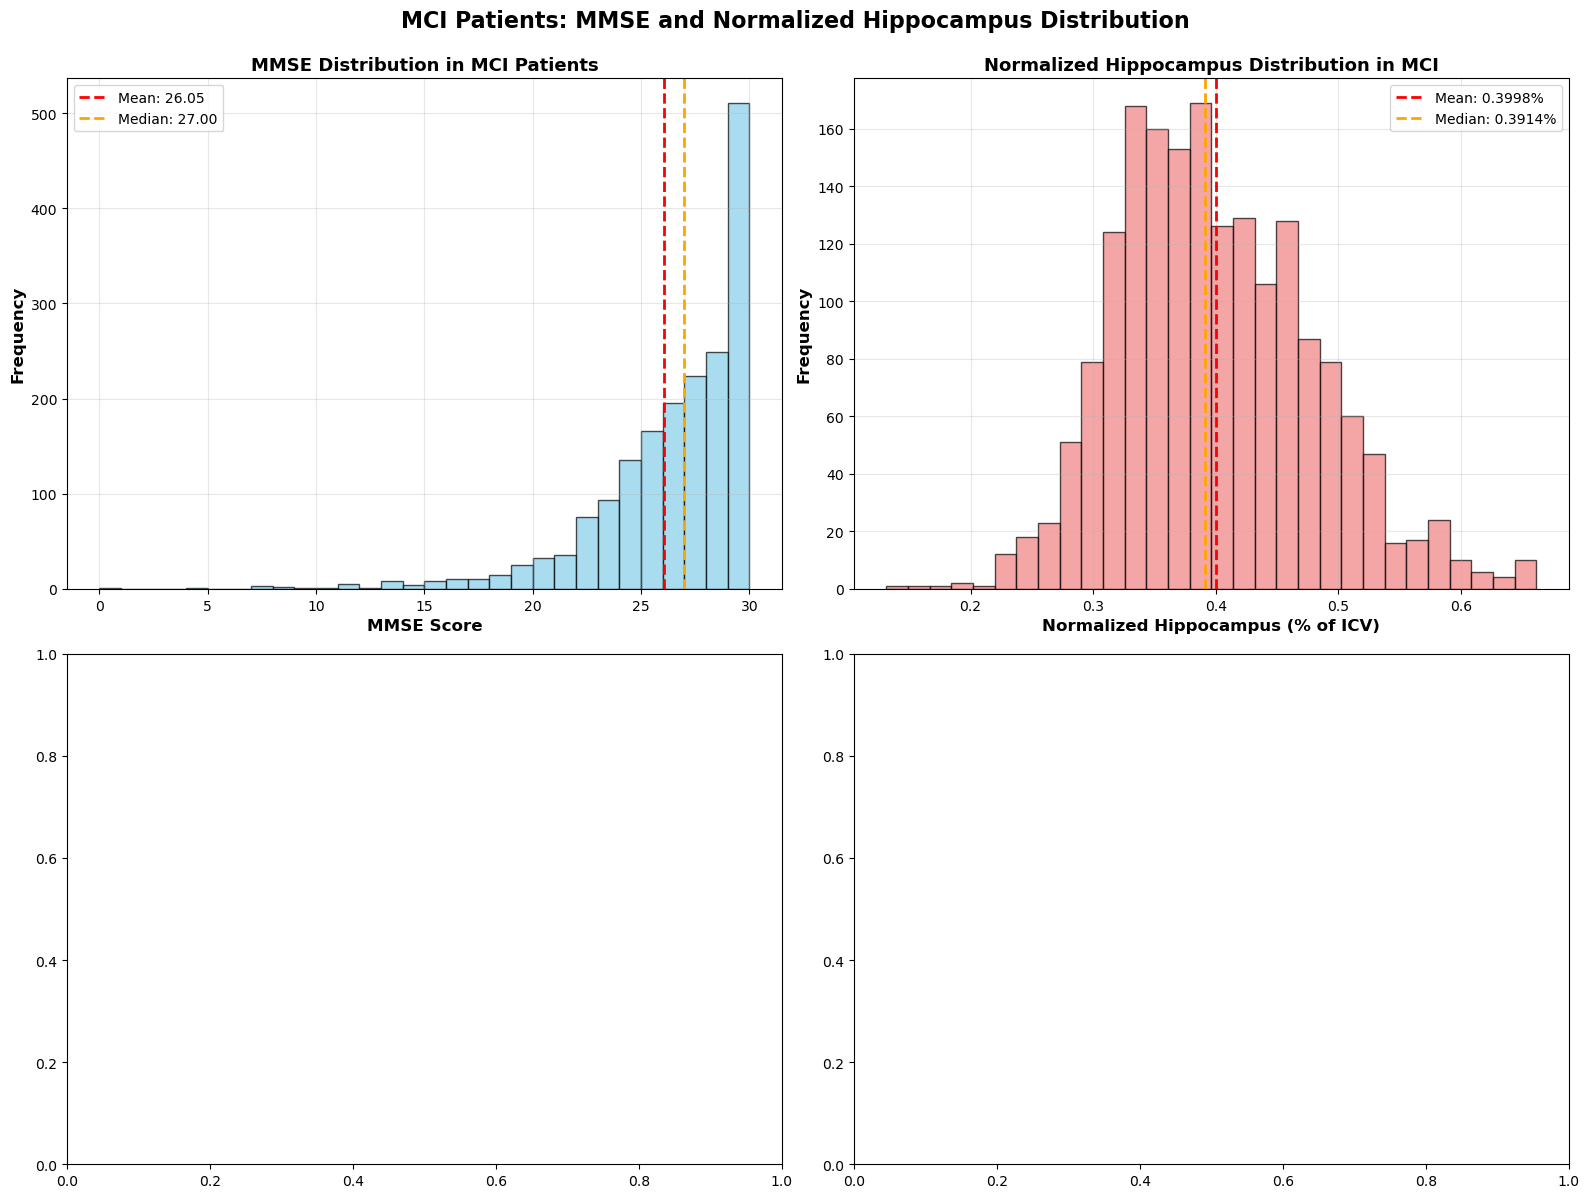

In [36]:
# 2. MCI Patients: MMSE and Normalized Hippocampus Distribution

import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print("MCI PATIENTS DISTRIBUTION ANALYSIS")
print("="*80)

# Filter MCI patients
df_mci = df[df['Group-RS:InitialDX'].isin(['MCI'])].copy()

print(f"\n📊 MCI Patients Overview:")
print(f"  Total MCI observations: {len(df_mci):,}")
print(f"  Unique subjects: {df_mci['Subject'].nunique():,}")

# Calculate normalized Hippocampus (using ICV)
df_mci['Hippocampus_normalized'] = (df_mci['Hippocampus'] / df_mci['ICV']) * 100  # in percentage

# Remove missing values for visualization
df_mci_vis = df_mci[['MMSE', 'Hippocampus_normalized']].dropna()

print(f"\n📊 Data Statistics (after removing NaN):")
print(f"  Valid observations: {len(df_mci_vis):,}")

print(f"\n  MMSE:")
print(f"    Mean: {df_mci_vis['MMSE'].mean():.2f} ± {df_mci_vis['MMSE'].std():.2f}")
print(f"    Median: {df_mci_vis['MMSE'].median():.2f}")
print(f"    Range: [{df_mci_vis['MMSE'].min():.0f}, {df_mci_vis['MMSE'].max():.0f}]")

print(f"\n  Normalized Hippocampus (% of ICV):")
print(f"    Mean: {df_mci_vis['Hippocampus_normalized'].mean():.4f}%")
print(f"    Std:  {df_mci_vis['Hippocampus_normalized'].std():.4f}%")
print(f"    Median: {df_mci_vis['Hippocampus_normalized'].median():.4f}%")
print(f"    Range: [{df_mci_vis['Hippocampus_normalized'].min():.4f}%, {df_mci_vis['Hippocampus_normalized'].max():.4f}%]")

# ============================================================================
# VISUALIZATION
# ============================================================================
print("\n" + "="*80)
print("Creating Visualizations...")
print("="*80)

fig, axes = plt.subplots(2,2, figsize=(16, 12))
fig.suptitle('MCI Patients: MMSE and Normalized Hippocampus Distribution', 
             fontsize=16, fontweight='bold', y=0.995)

# 1. MMSE Distribution (Histogram)
ax1 = axes[0,0]
ax1.hist(df_mci_vis['MMSE'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
ax1.axvline(df_mci_vis['MMSE'].mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {df_mci_vis["MMSE"].mean():.2f}')
ax1.axvline(df_mci_vis['MMSE'].median(), color='orange', linestyle='--', linewidth=2,
            label=f'Median: {df_mci_vis["MMSE"].median():.2f}')
ax1.set_xlabel('MMSE Score', fontweight='bold', fontsize=12)
ax1.set_ylabel('Frequency', fontweight='bold', fontsize=12)
ax1.set_title('MMSE Distribution in MCI Patients', fontweight='bold', fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# 2. Normalized Hippocampus Distribution (Histogram)
ax2 = axes[0,1]
ax2.hist(df_mci_vis['Hippocampus_normalized'], bins=30, edgecolor='black', alpha=0.7, color='lightcoral')
ax2.axvline(df_mci_vis['Hippocampus_normalized'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {df_mci_vis["Hippocampus_normalized"].mean():.4f}%')
ax2.axvline(df_mci_vis['Hippocampus_normalized'].median(), color='orange', linestyle='--', linewidth=2,
            label=f'Median: {df_mci_vis["Hippocampus_normalized"].median():.4f}%')
ax2.set_xlabel('Normalized Hippocampus (% of ICV)', fontweight='bold', fontsize=12)
ax2.set_ylabel('Frequency', fontweight='bold', fontsize=12)
ax2.set_title('Normalized Hippocampus Distribution in MCI', fontweight='bold', fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)


# ============================================================================
# ADDITIONAL PLOT: MMSE vs Normalized Hippocampus
# ============================================================================
# fig2, ax = plt.subplots(1, 1, figsize=(12, 8))

# # Scatter plot with density coloring
# scatter = ax.scatter(df_mci_vis['Hippocampus_normalized'], df_mci_vis['MMSE'],
#                      alpha=0.5, s=40, c=df_mci_vis['MMSE'], cmap='viridis')

# # Add regression line
# from scipy import stats as scipy_stats
# slope, intercept, r_value, p_value, std_err = scipy_stats.linregress(
#     df_mci_vis['Hippocampus_normalized'], df_mci_vis['MMSE']
# )
# line_x = np.array([df_mci_vis['Hippocampus_normalized'].min(), 
#                    df_mci_vis['Hippocampus_normalized'].max()])
# line_y = slope * line_x + intercept
# ax.plot(line_x, line_y, 'r--', linewidth=2, 
#         label=f'R² = {r_value**2:.3f}, p = {p_value:.3e}')

# ax.set_xlabel('Normalized Hippocampus (% of ICV)', fontweight='bold', fontsize=12)
# ax.set_ylabel('MMSE Score', fontweight='bold', fontsize=12)
# ax.set_title('MMSE vs Normalized Hippocampus in MCI Patients', 
#              fontweight='bold', fontsize=14)
# ax.legend(fontsize=11)
# ax.grid(alpha=0.3)

# Add colorbar
# cbar = plt.colorbar(scatter, ax=ax)
# cbar.set_label('MMSE Score', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()


MCI vs AD: DISTRIBUTION ANALYSIS

📊 Group Overview:
  MCI observations: 1,812
  AD observations: 921
  MCI unique subjects: 387
  AD unique subjects: 319

Creating Visualizations...


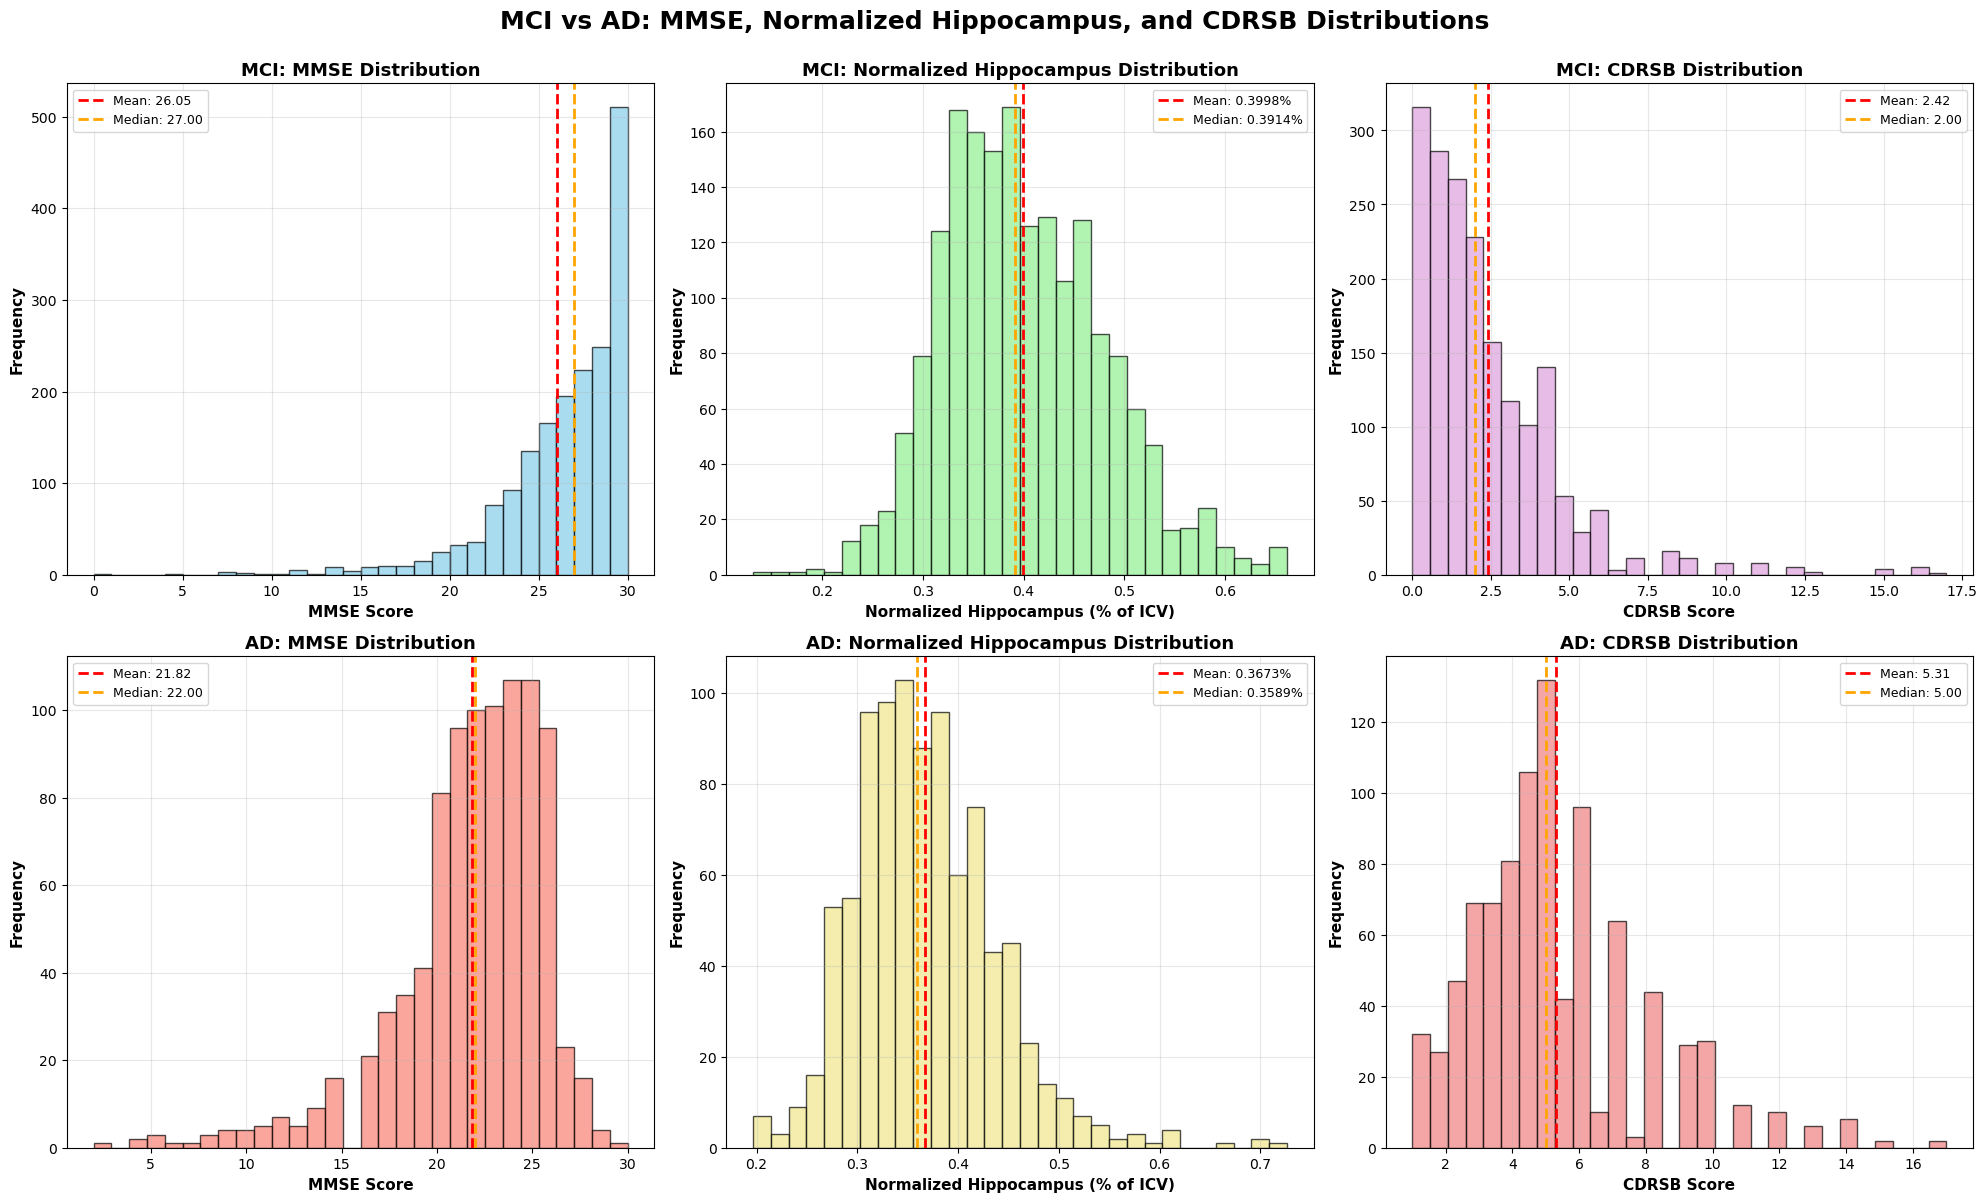


SUMMARY STATISTICS

📊 MCI GROUP:
  MMSE: Mean=26.05 ± 3.62, Range=[0, 30]
  Hippocampus: Mean=0.3998% ± 0.0801%, Range=[0.1314%, 0.6614%]
  CDRSB: Mean=2.42 ± 2.19, Range=[0.0, 17.0]

📊 AD GROUP:
  MMSE: Mean=21.82 ± 3.98, Range=[2, 30]
  Hippocampus: Mean=0.3673% ± 0.0701%, Range=[0.1964%, 0.7265%]
  CDRSB: Mean=5.31 ± 2.52, Range=[1.0, 17.0]


In [37]:
# 3. MCI and AD Distribution Comparison: MMSE, Hippocampus, CDRSB

import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print("MCI vs AD: DISTRIBUTION ANALYSIS")
print("="*80)

# Filter MCI and AD patients
df_mci = df[df['Group-RS:InitialDX'].isin(['MCI'])].copy()
df_ad = df[df['Group-RS:InitialDX'].isin(['AD'])].copy()

print(f"\n📊 Group Overview:")
print(f"  MCI observations: {len(df_mci):,}")
print(f"  AD observations: {len(df_ad):,}")
print(f"  MCI unique subjects: {df_mci['Subject'].nunique():,}")
print(f"  AD unique subjects: {df_ad['Subject'].nunique():,}")

# Calculate normalized Hippocampus (using ICV)
df_mci['Hippocampus_normalized'] = (df_mci['Hippocampus'] / df_mci['ICV']) * 100
df_ad['Hippocampus_normalized'] = (df_ad['Hippocampus'] / df_ad['ICV']) * 100

# ============================================================================
# VISUALIZATION
# ============================================================================
print("\n" + "="*80)
print("Creating Visualizations...")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('MCI vs AD: MMSE, Normalized Hippocampus, and CDRSB Distributions', 
             fontsize=18, fontweight='bold', y=0.998)

# MCI row
# 1. MCI - MMSE
ax1 = axes[0, 0]
df_mci_mmse = df_mci['MMSE'].dropna()
ax1.hist(df_mci_mmse, bins=30, edgecolor='black', alpha=0.7, color='skyblue')
ax1.axvline(df_mci_mmse.mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {df_mci_mmse.mean():.2f}')
ax1.axvline(df_mci_mmse.median(), color='orange', linestyle='--', linewidth=2,
            label=f'Median: {df_mci_mmse.median():.2f}')
ax1.set_xlabel('MMSE Score', fontweight='bold', fontsize=11)
ax1.set_ylabel('Frequency', fontweight='bold', fontsize=11)
ax1.set_title('MCI: MMSE Distribution', fontweight='bold', fontsize=13)
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# 2. MCI - Hippocampus
ax2 = axes[0, 1]
df_mci_hippo = df_mci['Hippocampus_normalized'].dropna()
ax2.hist(df_mci_hippo, bins=30, edgecolor='black', alpha=0.7, color='lightgreen')
ax2.axvline(df_mci_hippo.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {df_mci_hippo.mean():.4f}%')
ax2.axvline(df_mci_hippo.median(), color='orange', linestyle='--', linewidth=2,
            label=f'Median: {df_mci_hippo.median():.4f}%')
ax2.set_xlabel('Normalized Hippocampus (% of ICV)', fontweight='bold', fontsize=11)
ax2.set_ylabel('Frequency', fontweight='bold', fontsize=11)
ax2.set_title('MCI: Normalized Hippocampus Distribution', fontweight='bold', fontsize=13)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

# 3. MCI - CDRSB
ax3 = axes[0, 2]
df_mci_cdrsb = df_mci['CDRSB'].dropna()
ax3.hist(df_mci_cdrsb, bins=30, edgecolor='black', alpha=0.7, color='plum')
ax3.axvline(df_mci_cdrsb.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {df_mci_cdrsb.mean():.2f}')
ax3.axvline(df_mci_cdrsb.median(), color='orange', linestyle='--', linewidth=2,
            label=f'Median: {df_mci_cdrsb.median():.2f}')
ax3.set_xlabel('CDRSB Score', fontweight='bold', fontsize=11)
ax3.set_ylabel('Frequency', fontweight='bold', fontsize=11)
ax3.set_title('MCI: CDRSB Distribution', fontweight='bold', fontsize=13)
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3)

# AD row
# 4. AD - MMSE
ax4 = axes[1, 0]
df_ad_mmse = df_ad['MMSE'].dropna()
ax4.hist(df_ad_mmse, bins=30, edgecolor='black', alpha=0.7, color='salmon')
ax4.axvline(df_ad_mmse.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {df_ad_mmse.mean():.2f}')
ax4.axvline(df_ad_mmse.median(), color='orange', linestyle='--', linewidth=2,
            label=f'Median: {df_ad_mmse.median():.2f}')
ax4.set_xlabel('MMSE Score', fontweight='bold', fontsize=11)
ax4.set_ylabel('Frequency', fontweight='bold', fontsize=11)
ax4.set_title('AD: MMSE Distribution', fontweight='bold', fontsize=13)
ax4.legend(fontsize=9)
ax4.grid(alpha=0.3)

# 5. AD - Hippocampus
ax5 = axes[1, 1]
df_ad_hippo = df_ad['Hippocampus_normalized'].dropna()
ax5.hist(df_ad_hippo, bins=30, edgecolor='black', alpha=0.7, color='khaki')
ax5.axvline(df_ad_hippo.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {df_ad_hippo.mean():.4f}%')
ax5.axvline(df_ad_hippo.median(), color='orange', linestyle='--', linewidth=2,
            label=f'Median: {df_ad_hippo.median():.4f}%')
ax5.set_xlabel('Normalized Hippocampus (% of ICV)', fontweight='bold', fontsize=11)
ax5.set_ylabel('Frequency', fontweight='bold', fontsize=11)
ax5.set_title('AD: Normalized Hippocampus Distribution', fontweight='bold', fontsize=13)
ax5.legend(fontsize=9)
ax5.grid(alpha=0.3)

# 6. AD - CDRSB
ax6 = axes[1, 2]
df_ad_cdrsb = df_ad['CDRSB'].dropna()
ax6.hist(df_ad_cdrsb, bins=30, edgecolor='black', alpha=0.7, color='lightcoral')
ax6.axvline(df_ad_cdrsb.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {df_ad_cdrsb.mean():.2f}')
ax6.axvline(df_ad_cdrsb.median(), color='orange', linestyle='--', linewidth=2,
            label=f'Median: {df_ad_cdrsb.median():.2f}')
ax6.set_xlabel('CDRSB Score', fontweight='bold', fontsize=11)
ax6.set_ylabel('Frequency', fontweight='bold', fontsize=11)
ax6.set_title('AD: CDRSB Distribution', fontweight='bold', fontsize=13)
ax6.legend(fontsize=9)
ax6.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

print("\n📊 MCI GROUP:")
print(f"  MMSE: Mean={df_mci_mmse.mean():.2f} ± {df_mci_mmse.std():.2f}, Range=[{df_mci_mmse.min():.0f}, {df_mci_mmse.max():.0f}]")
print(f"  Hippocampus: Mean={df_mci_hippo.mean():.4f}% ± {df_mci_hippo.std():.4f}%, Range=[{df_mci_hippo.min():.4f}%, {df_mci_hippo.max():.4f}%]")
print(f"  CDRSB: Mean={df_mci_cdrsb.mean():.2f} ± {df_mci_cdrsb.std():.2f}, Range=[{df_mci_cdrsb.min():.1f}, {df_mci_cdrsb.max():.1f}]")

print("\n📊 AD GROUP:")
print(f"  MMSE: Mean={df_ad_mmse.mean():.2f} ± {df_ad_mmse.std():.2f}, Range=[{df_ad_mmse.min():.0f}, {df_ad_mmse.max():.0f}]")
print(f"  Hippocampus: Mean={df_ad_hippo.mean():.4f}% ± {df_ad_hippo.std():.4f}%, Range=[{df_ad_hippo.min():.4f}%, {df_ad_hippo.max():.4f}%]")
print(f"  CDRSB: Mean={df_ad_cdrsb.mean():.2f} ± {df_ad_cdrsb.std():.2f}, Range=[{df_ad_cdrsb.min():.1f}, {df_ad_cdrsb.max():.1f}]")

In [38]:
# 4. median-Based Categorization (Statistical Approach)

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as scipy_stats

print("="*80)
print("median-BASED CATEGORIZATION")
print("="*80)

# ============================================================================
# PREPARE DATA
# ============================================================================
# Filter MCI and AD patients
df_mci = df[df['Group-RS:InitialDX'].isin(['MCI'])].copy()
df_ad = df[df['Group-RS:InitialDX'].isin(['AD'])].copy()

# Calculate normalized Hippocampus (using ICV)
df_mci['Hippocampus_normalized'] = (df_mci['Hippocampus'] / df_mci['ICV']) * 100
df_ad['Hippocampus_normalized'] = (df_ad['Hippocampus'] / df_ad['ICV']) * 100

print(f"\n📊 Data Overview:")
print(f"  MCI observations: {len(df_mci):,}")
print(f"  AD observations: {len(df_ad):,}")

# ============================================================================
# FUNCTION: CATEGORIZE USING medianS
# ============================================================================
def categorize_binary(series, variable_name):
    """
    Categorize a variable into Low, High based on median (50%)
    Returns categorized series and cut-off points
    """
    # Remove NaN values
    series_clean = series.dropna()
    
    # Calculate median cut-off
    q50 = series_clean.quantile(0.5)
    
    # Categorize
    categories = pd.cut(series_clean, 
                       bins=[-np.inf, q50, np.inf],
                       labels=[\'Low\', \'High\'])
    
    # Statistics by category
    stats_dict = {
        'Low': {
            'n': (categories == 'Low').sum(),
            'mean': series_clean[categories == 'Low'].mean(),
            'std': series_clean[categories == 'Low'].std(),
            'range': (series_clean[categories == 'Low'].min(),
                     series_clean[categories == 'Low'].max())
        },
        'High': {
            'n': (categories == 'High').sum(),
            'mean': series_clean[categories == 'High'].mean(),
            'std': series_clean[categories == 'High'].std(),
            'range': (series_clean[categories == 'High'].min(),
                     series_clean[categories == 'High'].max())
        }
    }
    
    return categories, q50, stats_dict

# ============================================================================
# MCI GROUP CATEGORIZATION
# ============================================================================
print("\n" + "="*80)
print("MCI GROUP - median CATEGORIZATION")
print("="*80)

# Variables to categorize
variables = ['MMSE', 'Hippocampus_normalized', 'CDRSB']
mci_categories = {}
mci_cutoffs = {}
mci_stats = {}

for var in variables:
    print(f"\n{'='*50}")
    print(f"  {var}")
    print(f"{'='*50}")
    
    cat, q50, stats = categorize_binary(df_mci[var], var)
    mci_categories[var] = cat
    mci_cutoffs[var] = {\'q50\': q50}
    mci_stats[var] = stats
    
    print(f"  Cut-off points:")
    print(f"    33rd percentile: {q33:.4f}")
    print(f"    67th percentile: {q67:.4f}")
    print(f"\n  Category Statistics:")
    for cat_name in ['Low', 'Medium', 'High']:
        s = stats[cat_name]
        print(f"    {cat_name}: n={s['n']:,}, mean={s['mean']:.4f}±{s['std']:.4f}, range=[{s['range'][0]:.4f}, {s['range'][1]:.4f}]")

# ============================================================================
# AD GROUP CATEGORIZATION
# ============================================================================
print("\n" + "="*80)
print("AD GROUP - median CATEGORIZATION")
print("="*80)

ad_categories = {}
ad_cutoffs = {}
ad_stats = {}

for var in variables:
    print(f"\n{'='*50}")
    print(f"  {var}")
    print(f"{'='*50}")
    
    cat, q50, stats = categorize_binary(df_ad[var], var)
    ad_categories[var] = cat
    ad_cutoffs[var] = {\'q50\': q50}
    ad_stats[var] = stats
    
    print(f"  Cut-off points:")
    print(f"    33rd percentile: {q33:.4f}")
    print(f"    67th percentile: {q67:.4f}")
    print(f"\n  Category Statistics:")
    for cat_name in ['Low', 'Medium', 'High']:
        s = stats[cat_name]
        print(f"    {cat_name}: n={s['n']:,}, mean={s['mean']:.4f}±{s['std']:.4f}, range=[{s['range'][0]:.4f}, {s['range'][1]:.4f}]")

# ============================================================================
# STATISTICAL VALIDATION: CHI-SQUARE TEST
# ============================================================================
print("\n" + "="*80)
print("STATISTICAL VALIDATION - CHI-SQUARE TEST")
print("="*80)
print("Testing if the observed category distribution differs from uniform distribution (33.3% each)")

for var in variables:
    print(f"\n  {var}:")
    for group_name, cats in [('MCI', mci_categories), ('AD', ad_categories)]:
        observed = cats[var].value_counts().sort_index()
        expected = [len(cats[var]) / 3] * 3  # Expected uniform distribution
        chi2, p_value = scipy_stats.chisquare(observed, expected)
        print(f"    {group_name}: χ² = {chi2:.4f}, p-value = {p_value:.4f}")
        if p_value > 0.05:
            print(f"          → Distribution is uniform (not significantly different)")
        else:
            print(f"          → Distribution is NOT uniform (significantly different)")

print("\n" + "="*80)
print("Categorization Complete!")
print("="*80)

TERTILE-BASED CATEGORIZATION

📊 Data Overview:
  MCI observations: 1,812
  AD observations: 921

MCI GROUP - TERTILE CATEGORIZATION

  MMSE
  Cut-off points:
    33rd percentile: 25.0000
    67th percentile: 28.0000

  Category Statistics:
    Low: n=633, mean=22.2417±3.4490, range=[0.0000, 25.0000]
    Medium: n=668, mean=27.0808±0.8119, range=[26.0000, 28.0000]
    High: n=511, mean=29.4070±0.4918, range=[29.0000, 30.0000]

  Hippocampus_normalized
  Cut-off points:
    33rd percentile: 0.3567
    67th percentile: 0.4300

  Category Statistics:
    Low: n=604, mean=0.3163±0.0326, range=[0.1314, 0.3566]
    Medium: n=604, mean=0.3921±0.0207, range=[0.3570, 0.4299]
    High: n=604, mean=0.4910±0.0491, range=[0.4300, 0.6614]

  CDRSB
  Cut-off points:
    33rd percentile: 1.5000
    67th percentile: 2.5000

  Category Statistics:
    Low: n=869, mean=0.9333±0.4705, range=[0.0000, 1.5000]
    Medium: n=385, mean=2.2039±0.2460, range=[2.0000, 2.5000]
    High: n=558, mean=4.8710±2.3998, r

CATEGORY DISTRIBUTION VISUALIZATION


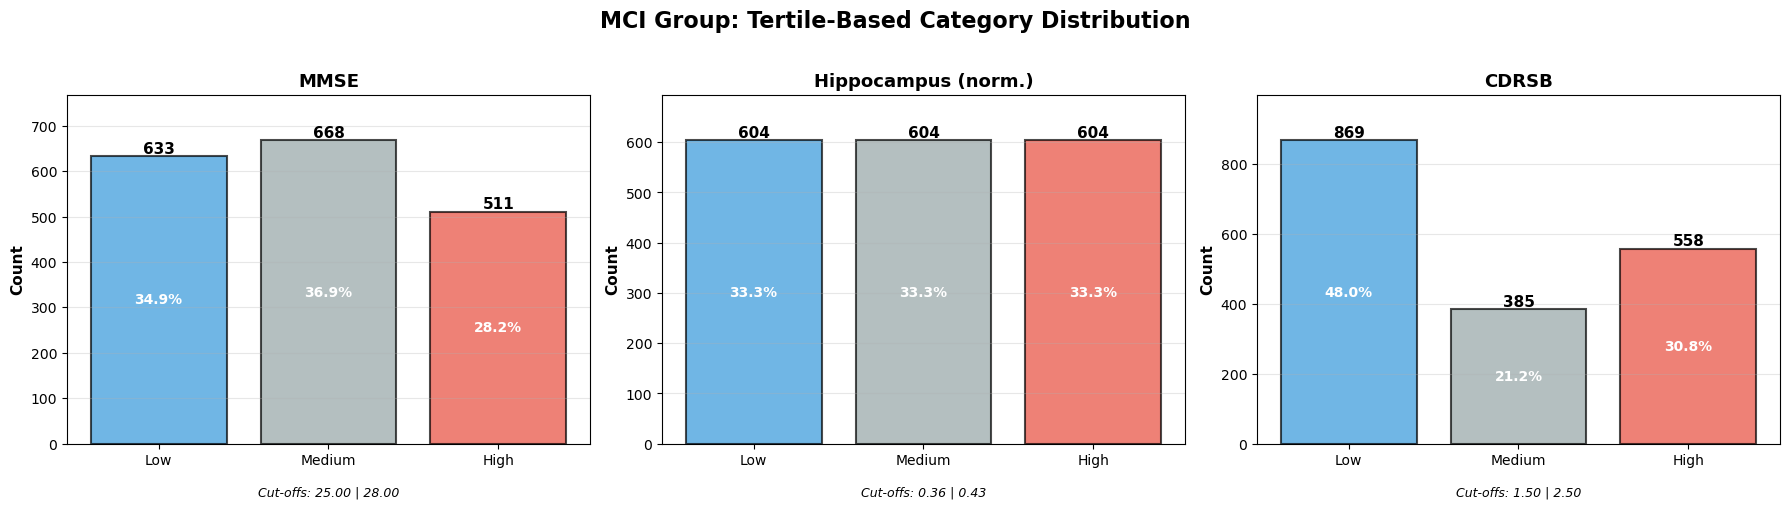

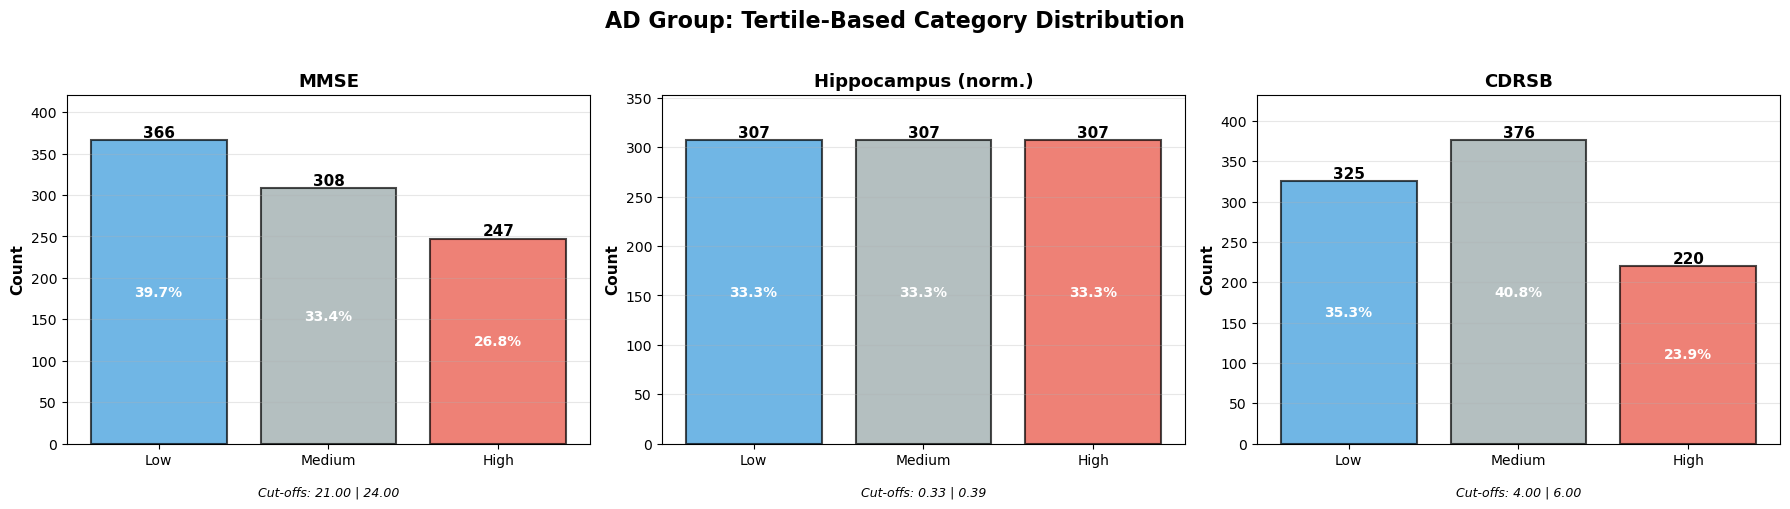

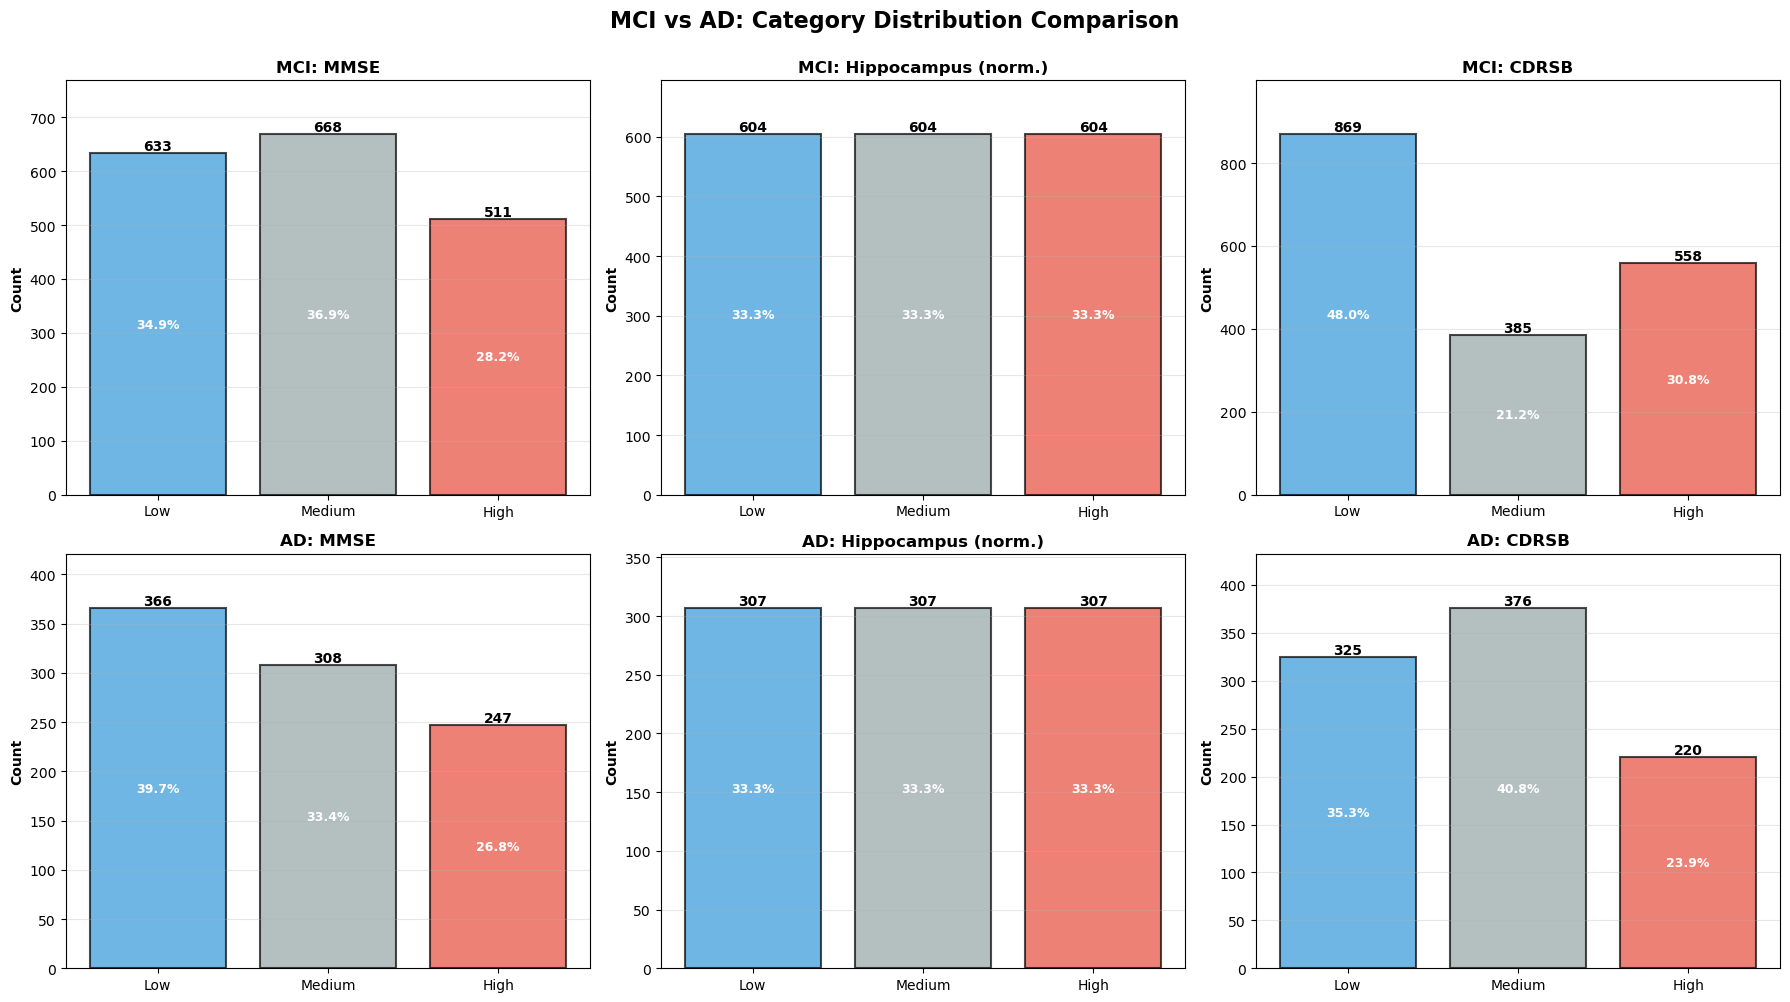


Visualization Complete!


In [39]:
# 5. Visualize Category Distributions

import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print("CATEGORY DISTRIBUTION VISUALIZATION")
print("="*80)

# ============================================================================
# FIGURE 1: MCI Category Distribution
# ============================================================================
fig1, axes1 = plt.subplots(1, 3, figsize=(18, 5))
fig1.suptitle('MCI Group: median-Based Category Distribution', 
              fontsize=16, fontweight='bold', y=1.02)

colors = ['#3498db', '#95a5a6', '#e74c3c']  # Blue, Gray, Red for Low, Medium, High

for idx, var in enumerate(variables):
    ax = axes1[idx]
    
    # Count categories
    counts = mci_categories[var].value_counts().sort_index()
    categories_ordered = ['Low', 'Medium', 'High']
    counts_ordered = [counts.get(cat, 0) for cat in categories_ordered]
    
    # Create bar plot
    bars = ax.bar(categories_ordered, counts_ordered, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    # Add percentage labels
    total = sum(counts_ordered)
    for i, (cat, count) in enumerate(zip(categories_ordered, counts_ordered)):
        percentage = (count / total) * 100
        ax.text(i, count * 0.5, f'{percentage:.1f}%',
                ha='center', va='center', fontweight='bold', fontsize=10, color='white')
    
    # Labels and title
    var_name = 'Hippocampus (norm.)' if var == 'Hippocampus_normalized' else var
    ax.set_title(f'{var_name}', fontweight='bold', fontsize=13)
    ax.set_ylabel('Count', fontweight='bold', fontsize=11)
    ax.set_ylim(0, max(counts_ordered) * 1.15)
    ax.grid(axis='y', alpha=0.3)
    
    # Add cut-off info
    q33 = mci_cutoffs[var]['q33']
    q67 = mci_cutoffs[var]['q67']
    ax.text(0.5, -0.15, f'Cut-offs: {q33:.2f} | {q67:.2f}',
            transform=ax.transAxes, ha='center', fontsize=9, style='italic')

plt.tight_layout()
plt.show()

# ============================================================================
# FIGURE 2: AD Category Distribution
# ============================================================================
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
fig2.suptitle('AD Group: median-Based Category Distribution', 
              fontsize=16, fontweight='bold', y=1.02)

for idx, var in enumerate(variables):
    ax = axes2[idx]
    
    # Count categories
    counts = ad_categories[var].value_counts().sort_index()
    categories_ordered = ['Low', 'Medium', 'High']
    counts_ordered = [counts.get(cat, 0) for cat in categories_ordered]
    
    # Create bar plot
    bars = ax.bar(categories_ordered, counts_ordered, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    # Add percentage labels
    total = sum(counts_ordered)
    for i, (cat, count) in enumerate(zip(categories_ordered, counts_ordered)):
        percentage = (count / total) * 100
        ax.text(i, count * 0.5, f'{percentage:.1f}%',
                ha='center', va='center', fontweight='bold', fontsize=10, color='white')
    
    # Labels and title
    var_name = 'Hippocampus (norm.)' if var == 'Hippocampus_normalized' else var
    ax.set_title(f'{var_name}', fontweight='bold', fontsize=13)
    ax.set_ylabel('Count', fontweight='bold', fontsize=11)
    ax.set_ylim(0, max(counts_ordered) * 1.15)
    ax.grid(axis='y', alpha=0.3)
    
    # Add cut-off info
    q33 = ad_cutoffs[var]['q33']
    q67 = ad_cutoffs[var]['q67']
    ax.text(0.5, -0.15, f'Cut-offs: {q33:.2f} | {q67:.2f}',
            transform=ax.transAxes, ha='center', fontsize=9, style='italic')

plt.tight_layout()
plt.show()

# ============================================================================
# FIGURE 3: Side-by-Side Comparison
# ============================================================================
fig3, axes3 = plt.subplots(2, 3, figsize=(18, 10))
fig3.suptitle('MCI vs AD: Category Distribution Comparison', 
              fontsize=16, fontweight='bold', y=0.998)

# MCI row
for idx, var in enumerate(variables):
    ax = axes3[0, idx]
    
    # Count categories
    counts = mci_categories[var].value_counts().sort_index()
    categories_ordered = ['Low', 'Medium', 'High']
    counts_ordered = [counts.get(cat, 0) for cat in categories_ordered]
    
    # Create bar plot
    bars = ax.bar(categories_ordered, counts_ordered, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    # Add percentage labels
    total = sum(counts_ordered)
    for i, (cat, count) in enumerate(zip(categories_ordered, counts_ordered)):
        percentage = (count / total) * 100
        ax.text(i, count * 0.5, f'{percentage:.1f}%',
                ha='center', va='center', fontweight='bold', fontsize=9, color='white')
    
    # Labels and title
    var_name = 'Hippocampus (norm.)' if var == 'Hippocampus_normalized' else var
    ax.set_title(f'MCI: {var_name}', fontweight='bold', fontsize=12)
    ax.set_ylabel('Count', fontweight='bold', fontsize=10)
    ax.set_ylim(0, max(counts_ordered) * 1.15)
    ax.grid(axis='y', alpha=0.3)

# AD row
for idx, var in enumerate(variables):
    ax = axes3[1, idx]
    
    # Count categories
    counts = ad_categories[var].value_counts().sort_index()
    categories_ordered = ['Low', 'Medium', 'High']
    counts_ordered = [counts.get(cat, 0) for cat in categories_ordered]
    
    # Create bar plot
    bars = ax.bar(categories_ordered, counts_ordered, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    # Add percentage labels
    total = sum(counts_ordered)
    for i, (cat, count) in enumerate(zip(categories_ordered, counts_ordered)):
        percentage = (count / total) * 100
        ax.text(i, count * 0.5, f'{percentage:.1f}%',
                ha='center', va='center', fontweight='bold', fontsize=9, color='white')
    
    # Labels and title
    var_name = 'Hippocampus (norm.)' if var == 'Hippocampus_normalized' else var
    ax.set_title(f'AD: {var_name}', fontweight='bold', fontsize=12)
    ax.set_ylabel('Count', fontweight='bold', fontsize=10)
    ax.set_ylim(0, max(counts_ordered) * 1.15)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("Visualization Complete!")
print("="*80)

In [40]:
# 6. Hippocampus Bottom 30% - MMSE Category Distribution

print("="*80)
print("HIPPOCAMPUS LOW GROUP - MMSE CATEGORY DISTRIBUTION")
print("="*80)

# MCI: Hippocampus Low 환자들
mci_hippo_low_idx = mci_categories['Hippocampus_normalized'][mci_categories['Hippocampus_normalized'] == 'Low'].index
mci_mmse_low = df_mci.loc[mci_hippo_low_idx, 'MMSE']
mci_mmse_categories_low = mci_categories['MMSE'].reindex(mci_hippo_low_idx)

print("\n📊 MCI - Hippocampus Low (n=604):")
mmse_dist_mci = mci_mmse_categories_low.value_counts().sort_index()
for cat in ['Low', 'Medium', 'High']:
    count = mmse_dist_mci.get(cat, 0)
    pct = (count / len(mci_mmse_categories_low)) * 100
    print(f"  MMSE {cat:6s}: {count:3d} ({pct:5.1f}%)")

# AD: Hippocampus Low 환자들
ad_hippo_low_idx = ad_categories['Hippocampus_normalized'][ad_categories['Hippocampus_normalized'] == 'Low'].index
ad_mmse_low = df_ad.loc[ad_hippo_low_idx, 'MMSE']
ad_mmse_categories_low = ad_categories['MMSE'].reindex(ad_hippo_low_idx)

print("\n📊 AD - Hippocampus Low (n=307):")
mmse_dist_ad = ad_mmse_categories_low.value_counts().sort_index()
for cat in ['Low', 'Medium', 'High']:
    count = mmse_dist_ad.get(cat, 0)
    pct = (count / len(ad_mmse_categories_low)) * 100
    print(f"  MMSE {cat:6s}: {count:3d} ({pct:5.1f}%)")

HIPPOCAMPUS LOW GROUP - MMSE CATEGORY DISTRIBUTION

📊 MCI - Hippocampus Low (n=604):
  MMSE Low   : 313 ( 51.8%)
  MMSE Medium: 208 ( 34.4%)
  MMSE High  :  83 ( 13.7%)

📊 AD - Hippocampus Low (n=307):
  MMSE Low   : 151 ( 49.2%)
  MMSE Medium:  95 ( 30.9%)
  MMSE High  :  61 ( 19.9%)


In [41]:
# 7. High Cognitive Reserve Group Analysis
# (Hippocampus Low + MMSE High vs Hippocampus Low + MMSE Low)

print("="*80)
print("COGNITIVE RESERVE ANALYSIS")
print("="*80)

# ============================================================================
# DEFINE GROUPS
# ============================================================================
# MCI Groups
mci_hippo_low_idx = mci_categories['Hippocampus_normalized'][mci_categories['Hippocampus_normalized'] == 'Low'].index
mci_mmse_cats = mci_categories['MMSE'].reindex(mci_hippo_low_idx)

mci_high_reserve = df_mci.loc[mci_hippo_low_idx[mci_mmse_cats == 'High']].copy()  # Hippo Low + MMSE High
mci_low_reserve = df_mci.loc[mci_hippo_low_idx[mci_mmse_cats == 'Low']].copy()   # Hippo Low + MMSE Low

# AD Groups
ad_hippo_low_idx = ad_categories['Hippocampus_normalized'][ad_categories['Hippocampus_normalized'] == 'Low'].index
ad_mmse_cats = ad_categories['MMSE'].reindex(ad_hippo_low_idx)

ad_high_reserve = df_ad.loc[ad_hippo_low_idx[ad_mmse_cats == 'High']].copy()
ad_low_reserve = df_ad.loc[ad_hippo_low_idx[ad_mmse_cats == 'Low']].copy()

print(f"\n📊 Group Sizes:")
print(f"  MCI - High Reserve (Hippo Low + MMSE High): {len(mci_high_reserve):3d}")
print(f"  MCI - Low Reserve  (Hippo Low + MMSE Low):  {len(mci_low_reserve):3d}")
print(f"  AD  - High Reserve (Hippo Low + MMSE High): {len(ad_high_reserve):3d}")
print(f"  AD  - Low Reserve  (Hippo Low + MMSE Low):  {len(ad_low_reserve):3d}")

# ============================================================================
# EDUCATION LEVEL COMPARISON
# ============================================================================
print("\n" + "="*80)
print("EDUCATION LEVEL (PTEDUCAT)")
print("="*80)

from scipy import stats as scipy_stats

# MCI
print("\n📊 MCI:")
print(f"  High Reserve: {mci_high_reserve['PTEDUCAT'].mean():.2f} ± {mci_high_reserve['PTEDUCAT'].std():.2f} years (n={mci_high_reserve['PTEDUCAT'].notna().sum()})")
print(f"  Low Reserve:  {mci_low_reserve['PTEDUCAT'].mean():.2f} ± {mci_low_reserve['PTEDUCAT'].std():.2f} years (n={mci_low_reserve['PTEDUCAT'].notna().sum()})")
t_stat, p_val = scipy_stats.ttest_ind(mci_high_reserve['PTEDUCAT'].dropna(), 
                                       mci_low_reserve['PTEDUCAT'].dropna())
print(f"  t-test: t={t_stat:.3f}, p={p_val:.4f} {'***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'}")

# AD
print("\n📊 AD:")
print(f"  High Reserve: {ad_high_reserve['PTEDUCAT'].mean():.2f} ± {ad_high_reserve['PTEDUCAT'].std():.2f} years (n={ad_high_reserve['PTEDUCAT'].notna().sum()})")
print(f"  Low Reserve:  {ad_low_reserve['PTEDUCAT'].mean():.2f} ± {ad_low_reserve['PTEDUCAT'].std():.2f} years (n={ad_low_reserve['PTEDUCAT'].notna().sum()})")
t_stat, p_val = scipy_stats.ttest_ind(ad_high_reserve['PTEDUCAT'].dropna(), 
                                       ad_low_reserve['PTEDUCAT'].dropna())
print(f"  t-test: t={t_stat:.3f}, p={p_val:.4f} {'***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'}")

# ============================================================================
# AGE COMPARISON
# ============================================================================
print("\n" + "="*80)
print("AGE")
print("="*80)

# MCI
print("\n📊 MCI:")
print(f"  High Reserve: {mci_high_reserve['AGE'].mean():.2f} ± {mci_high_reserve['AGE'].std():.2f} years")
print(f"  Low Reserve:  {mci_low_reserve['AGE'].mean():.2f} ± {mci_low_reserve['AGE'].std():.2f} years")
t_stat, p_val = scipy_stats.ttest_ind(mci_high_reserve['AGE'].dropna(), 
                                       mci_low_reserve['AGE'].dropna())
print(f"  t-test: t={t_stat:.3f}, p={p_val:.4f} {'***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'}")

# AD
print("\n📊 AD:")
print(f"  High Reserve: {ad_high_reserve['AGE'].mean():.2f} ± {ad_high_reserve['AGE'].std():.2f} years")
print(f"  Low Reserve:  {ad_low_reserve['AGE'].mean():.2f} ± {ad_low_reserve['AGE'].std():.2f} years")
t_stat, p_val = scipy_stats.ttest_ind(ad_high_reserve['AGE'].dropna(), 
                                       ad_low_reserve['AGE'].dropna())
print(f"  t-test: t={t_stat:.3f}, p={p_val:.4f} {'***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'}")

# ============================================================================
# GENDER COMPARISON
# ============================================================================
print("\n" + "="*80)
print("GENDER (PTGENDER)")
print("="*80)

# MCI
print("\n📊 MCI:")
mci_hr_gender = mci_high_reserve['PTGENDER'].value_counts()
mci_lr_gender = mci_low_reserve['PTGENDER'].value_counts()
print(f"  High Reserve: Male={mci_hr_gender.get('Male', 0)} ({mci_hr_gender.get('Male', 0)/len(mci_high_reserve)*100:.1f}%), Female={mci_hr_gender.get('Female', 0)} ({mci_hr_gender.get('Female', 0)/len(mci_high_reserve)*100:.1f}%)")
print(f"  Low Reserve:  Male={mci_lr_gender.get('Male', 0)} ({mci_lr_gender.get('Male', 0)/len(mci_low_reserve)*100:.1f}%), Female={mci_lr_gender.get('Female', 0)} ({mci_lr_gender.get('Female', 0)/len(mci_low_reserve)*100:.1f}%)")

# AD
print("\n📊 AD:")
ad_hr_gender = ad_high_reserve['PTGENDER'].value_counts()
ad_lr_gender = ad_low_reserve['PTGENDER'].value_counts()
print(f"  High Reserve: Male={ad_hr_gender.get('Male', 0)} ({ad_hr_gender.get('Male', 0)/len(ad_high_reserve)*100:.1f}%), Female={ad_hr_gender.get('Female', 0)} ({ad_hr_gender.get('Female', 0)/len(ad_high_reserve)*100:.1f}%)")
print(f"  Low Reserve:  Male={ad_lr_gender.get('Male', 0)} ({ad_lr_gender.get('Male', 0)/len(ad_low_reserve)*100:.1f}%), Female={ad_lr_gender.get('Female', 0)} ({ad_lr_gender.get('Female', 0)/len(ad_low_reserve)*100:.1f}%)")

# ============================================================================
# OTHER BRAIN MEASURES
# ============================================================================
print("\n" + "="*80)
print("OTHER BRAIN MEASURES")
print("="*80)

brain_vars = ['Ventricles', 'WholeBrain', 'Entorhinal', 'MidTemp']

for var in brain_vars:
    if var in df_mci.columns:
        print(f"\n📊 {var}:")
        
        # MCI
        mci_hr_mean = mci_high_reserve[var].mean()
        mci_hr_std = mci_high_reserve[var].std()
        mci_lr_mean = mci_low_reserve[var].mean()
        mci_lr_std = mci_low_reserve[var].std()
        
        print(f"  MCI High Reserve: {mci_hr_mean:.2f} ± {mci_hr_std:.2f}")
        print(f"  MCI Low Reserve:  {mci_lr_mean:.2f} ± {mci_lr_std:.2f}")
        
        t_stat, p_val = scipy_stats.ttest_ind(mci_high_reserve[var].dropna(), 
                                               mci_low_reserve[var].dropna())
        print(f"  MCI t-test: t={t_stat:.3f}, p={p_val:.4f} {'***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'}")
        
        # AD
        ad_hr_mean = ad_high_reserve[var].mean()
        ad_hr_std = ad_high_reserve[var].std()
        ad_lr_mean = ad_low_reserve[var].mean()
        ad_lr_std = ad_low_reserve[var].std()
        
        print(f"  AD High Reserve:  {ad_hr_mean:.2f} ± {ad_hr_std:.2f}")
        print(f"  AD Low Reserve:   {ad_lr_mean:.2f} ± {ad_lr_std:.2f}")
        
        t_stat, p_val = scipy_stats.ttest_ind(ad_high_reserve[var].dropna(), 
                                               ad_low_reserve[var].dropna())
        print(f"  AD t-test: t={t_stat:.3f}, p={p_val:.4f} {'***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'}")

COGNITIVE RESERVE ANALYSIS

📊 Group Sizes:
  MCI - High Reserve (Hippo Low + MMSE High):  83
  MCI - Low Reserve  (Hippo Low + MMSE Low):  313
  AD  - High Reserve (Hippo Low + MMSE High):  61
  AD  - Low Reserve  (Hippo Low + MMSE Low):  151

EDUCATION LEVEL (PTEDUCAT)

📊 MCI:
  High Reserve: 16.19 ± 2.64 years (n=83)
  Low Reserve:  15.54 ± 2.89 years (n=313)
  t-test: t=1.853, p=0.0646 ns

📊 AD:
  High Reserve: 15.03 ± 3.09 years (n=61)
  Low Reserve:  15.13 ± 3.08 years (n=151)
  t-test: t=-0.199, p=0.8424 ns

AGE

📊 MCI:
  High Reserve: 76.36 ± 5.98 years
  Low Reserve:  75.33 ± 6.21 years
  t-test: t=1.357, p=0.1754 ns

📊 AD:
  High Reserve: 78.49 ± 5.30 years
  Low Reserve:  77.34 ± 6.48 years
  t-test: t=1.226, p=0.2215 ns

GENDER (PTGENDER)

📊 MCI:
  High Reserve: Male=65 (78.3%), Female=18 (21.7%)
  Low Reserve:  Male=207 (66.1%), Female=106 (33.9%)

📊 AD:
  High Reserve: Male=39 (63.9%), Female=22 (36.1%)
  Low Reserve:  Male=82 (54.3%), Female=69 (45.7%)

OTHER BRAIN MEASUR

In [42]:
# 8. True Cognitive Reserve: Multiple Brain Regions ALL Low + MMSE High

print("="*80)
print("TRUE COGNITIVE RESERVE IDENTIFICATION")
print("Multiple Brain Regions ALL Low + MMSE High")
print("="*80)

# ============================================================================
# CATEGORIZE ADDITIONAL BRAIN REGIONS
# ============================================================================
brain_vars_to_categorize = ['WholeBrain', 'Entorhinal', 'MidTemp']

# MCI - Categorize additional brain measures
for var in brain_vars_to_categorize:
    cat, q50, stats = categorize_binary(df_mci[var], var)
    mci_categories[var] = cat
    mci_cutoffs[var] = {\'q50\': q50}

# AD - Categorize additional brain measures
for var in brain_vars_to_categorize:
    cat, q50, stats = categorize_binary(df_ad[var], var)
    ad_categories[var] = cat
    ad_cutoffs[var] = {\'q50\': q50}

print("\n✓ Additional brain regions categorized into medians")

# ============================================================================
# FIND TRUE CR: ALL BRAIN REGIONS LOW + MMSE HIGH
# ============================================================================
print("\n" + "="*80)
print("IDENTIFYING TRUE COGNITIVE RESERVE CASES")
print("="*80)

# MCI: Find cases with ALL brain regions Low
mci_all_brain_low = (
    (mci_categories['Hippocampus_normalized'] == 'Low') &
    (mci_categories['WholeBrain'] == 'Low') &
    (mci_categories['Entorhinal'] == 'Low') &
    (mci_categories['MidTemp'] == 'Low')
)

mci_all_brain_low_idx = mci_all_brain_low[mci_all_brain_low].index
mci_mmse_in_brain_low = mci_categories['MMSE'].reindex(mci_all_brain_low_idx)

# True CR: All brain Low + MMSE High
mci_true_cr_idx = mci_all_brain_low_idx[mci_mmse_in_brain_low == 'High']
mci_true_cr = df_mci.loc[mci_true_cr_idx].copy()

# Control: All brain Low + MMSE Low
mci_no_cr_idx = mci_all_brain_low_idx[mci_mmse_in_brain_low == 'Low']
mci_no_cr = df_mci.loc[mci_no_cr_idx].copy()

# AD: Find cases with ALL brain regions Low
ad_all_brain_low = (
    (ad_categories['Hippocampus_normalized'] == 'Low') &
    (ad_categories['WholeBrain'] == 'Low') &
    (ad_categories['Entorhinal'] == 'Low') &
    (ad_categories['MidTemp'] == 'Low')
)

ad_all_brain_low_idx = ad_all_brain_low[ad_all_brain_low].index
ad_mmse_in_brain_low = ad_categories['MMSE'].reindex(ad_all_brain_low_idx)

# True CR: All brain Low + MMSE High
ad_true_cr_idx = ad_all_brain_low_idx[ad_mmse_in_brain_low == 'High']
ad_true_cr = df_ad.loc[ad_true_cr_idx].copy()

# Control: All brain Low + MMSE Low
ad_no_cr_idx = ad_all_brain_low_idx[ad_mmse_in_brain_low == 'Low']
ad_no_cr = df_ad.loc[ad_no_cr_idx].copy()

print(f"\n📊 Sample Sizes:")
print(f"\n  MCI:")
print(f"    All brain regions Low (total):           {len(mci_all_brain_low_idx):3d}")
print(f"    └─ True CR (All brain Low + MMSE High):  {len(mci_true_cr):3d} ({len(mci_true_cr)/len(mci_all_brain_low_idx)*100:.1f}%)")
print(f"    └─ No CR   (All brain Low + MMSE Low):   {len(mci_no_cr):3d} ({len(mci_no_cr)/len(mci_all_brain_low_idx)*100:.1f}%)")

print(f"\n  AD:")
print(f"    All brain regions Low (total):           {len(ad_all_brain_low_idx):3d}")
print(f"    └─ True CR (All brain Low + MMSE High):  {len(ad_true_cr):3d} ({len(ad_true_cr)/len(ad_all_brain_low_idx)*100:.1f}%)")
print(f"    └─ No CR   (All brain Low + MMSE Low):   {len(ad_no_cr):3d} ({len(ad_no_cr)/len(ad_all_brain_low_idx)*100:.1f}%)")

# ============================================================================
# COMPARE TRUE CR vs NO CR
# ============================================================================
print("\n" + "="*80)
print("TRUE COGNITIVE RESERVE CHARACTERISTICS")
print("="*80)

# Education
print("\n📚 EDUCATION (PTEDUCAT):")
print(f"\n  MCI:")
print(f"    True CR: {mci_true_cr['PTEDUCAT'].mean():.2f} ± {mci_true_cr['PTEDUCAT'].std():.2f} years (n={mci_true_cr['PTEDUCAT'].notna().sum()})")
print(f"    No CR:   {mci_no_cr['PTEDUCAT'].mean():.2f} ± {mci_no_cr['PTEDUCAT'].std():.2f} years (n={mci_no_cr['PTEDUCAT'].notna().sum()})")
if len(mci_true_cr) > 0 and len(mci_no_cr) > 0:
    t_stat, p_val = scipy_stats.ttest_ind(mci_true_cr['PTEDUCAT'].dropna(), 
                                           mci_no_cr['PTEDUCAT'].dropna())
    print(f"    t-test: t={t_stat:.3f}, p={p_val:.4f} {'***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'}")

print(f"\n  AD:")
print(f"    True CR: {ad_true_cr['PTEDUCAT'].mean():.2f} ± {ad_true_cr['PTEDUCAT'].std():.2f} years (n={ad_true_cr['PTEDUCAT'].notna().sum()})")
print(f"    No CR:   {ad_no_cr['PTEDUCAT'].mean():.2f} ± {ad_no_cr['PTEDUCAT'].std():.2f} years (n={ad_no_cr['PTEDUCAT'].notna().sum()})")
if len(ad_true_cr) > 0 and len(ad_no_cr) > 0:
    t_stat, p_val = scipy_stats.ttest_ind(ad_true_cr['PTEDUCAT'].dropna(), 
                                           ad_no_cr['PTEDUCAT'].dropna())
    print(f"    t-test: t={t_stat:.3f}, p={p_val:.4f} {'***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'}")

# Age
print("\n🎂 AGE:")
print(f"\n  MCI:")
print(f"    True CR: {mci_true_cr['AGE'].mean():.2f} ± {mci_true_cr['AGE'].std():.2f} years")
print(f"    No CR:   {mci_no_cr['AGE'].mean():.2f} ± {mci_no_cr['AGE'].std():.2f} years")
if len(mci_true_cr) > 0 and len(mci_no_cr) > 0:
    t_stat, p_val = scipy_stats.ttest_ind(mci_true_cr['AGE'].dropna(), 
                                           mci_no_cr['AGE'].dropna())
    print(f"    t-test: t={t_stat:.3f}, p={p_val:.4f} {'***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'}")

print(f"\n  AD:")
print(f"    True CR: {ad_true_cr['AGE'].mean():.2f} ± {ad_true_cr['AGE'].std():.2f} years")
print(f"    No CR:   {ad_no_cr['AGE'].mean():.2f} ± {ad_no_cr['AGE'].std():.2f} years")
if len(ad_true_cr) > 0 and len(ad_no_cr) > 0:
    t_stat, p_val = scipy_stats.ttest_ind(ad_true_cr['AGE'].dropna(), 
                                           ad_no_cr['AGE'].dropna())
    print(f"    t-test: t={t_stat:.3f}, p={p_val:.4f} {'***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'}")

# Gender
print("\n👥 GENDER:")
print(f"\n  MCI:")
if len(mci_true_cr) > 0:
    mci_cr_gender = mci_true_cr['PTGENDER'].value_counts()
    print(f"    True CR: Male={mci_cr_gender.get('Male', 0)} ({mci_cr_gender.get('Male', 0)/len(mci_true_cr)*100:.1f}%), Female={mci_cr_gender.get('Female', 0)} ({mci_cr_gender.get('Female', 0)/len(mci_true_cr)*100:.1f}%)")
if len(mci_no_cr) > 0:
    mci_nocr_gender = mci_no_cr['PTGENDER'].value_counts()
    print(f"    No CR:   Male={mci_nocr_gender.get('Male', 0)} ({mci_nocr_gender.get('Male', 0)/len(mci_no_cr)*100:.1f}%), Female={mci_nocr_gender.get('Female', 0)} ({mci_nocr_gender.get('Female', 0)/len(mci_no_cr)*100:.1f}%)")

print(f"\n  AD:")
if len(ad_true_cr) > 0:
    ad_cr_gender = ad_true_cr['PTGENDER'].value_counts()
    print(f"    True CR: Male={ad_cr_gender.get('Male', 0)} ({ad_cr_gender.get('Male', 0)/len(ad_true_cr)*100:.1f}%), Female={ad_cr_gender.get('Female', 0)} ({ad_cr_gender.get('Female', 0)/len(ad_true_cr)*100:.1f}%)")
if len(ad_no_cr) > 0:
    ad_nocr_gender = ad_no_cr['PTGENDER'].value_counts()
    print(f"    No CR:   Male={ad_nocr_gender.get('Male', 0)} ({ad_nocr_gender.get('Male', 0)/len(ad_no_cr)*100:.1f}%), Female={ad_nocr_gender.get('Female', 0)} ({ad_nocr_gender.get('Female', 0)/len(ad_no_cr)*100:.1f}%)")

# MMSE scores
print("\n🧠 MMSE SCORES:")
print(f"\n  MCI:")
print(f"    True CR: {mci_true_cr['MMSE'].mean():.2f} ± {mci_true_cr['MMSE'].std():.2f}")
print(f"    No CR:   {mci_no_cr['MMSE'].mean():.2f} ± {mci_no_cr['MMSE'].std():.2f}")

print(f"\n  AD:")
print(f"    True CR: {ad_true_cr['MMSE'].mean():.2f} ± {ad_true_cr['MMSE'].std():.2f}")
print(f"    No CR:   {ad_no_cr['MMSE'].mean():.2f} ± {ad_no_cr['MMSE'].std():.2f}")

print("\n" + "="*80)
print("✓ True Cognitive Reserve analysis complete!")
print("="*80)

TRUE COGNITIVE RESERVE IDENTIFICATION
Multiple Brain Regions ALL Low + MMSE High

✓ Additional brain regions categorized into tertiles

IDENTIFYING TRUE COGNITIVE RESERVE CASES

📊 Sample Sizes:

  MCI:
    All brain regions Low (total):           168
    └─ True CR (All brain Low + MMSE High):   17 (10.1%)
    └─ No CR   (All brain Low + MMSE Low):   104 (61.9%)

  AD:
    All brain regions Low (total):            62
    └─ True CR (All brain Low + MMSE High):    4 (6.5%)
    └─ No CR   (All brain Low + MMSE Low):    43 (69.4%)

TRUE COGNITIVE RESERVE CHARACTERISTICS

📚 EDUCATION (PTEDUCAT):

  MCI:
    True CR: 16.29 ± 1.99 years (n=17)
    No CR:   15.96 ± 2.53 years (n=104)
    t-test: t=0.516, p=0.6071 ns

  AD:
    True CR: 12.75 ± 1.50 years (n=4)
    No CR:   14.77 ± 2.96 years (n=43)
    t-test: t=-1.338, p=0.1876 ns

🎂 AGE:

  MCI:
    True CR: 78.91 ± 4.84 years
    No CR:   76.18 ± 6.86 years
    t-test: t=1.575, p=0.1179 ns

  AD:
    True CR: 79.70 ± 6.89 years
    No CR: 

In [43]:
# 9. Subclustering: 2x2 MMSE × Hippocampus Groups

print("="*80)
print("SUBCLUSTERING ANALYSIS")
print("Finding hidden subgroups within 2×2 MMSE × Hippocampus categories")
print("="*80)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# CREATE 2x2 GROUPS (MMSE × Hippocampus)
# ============================================================================
print("\n" + "="*80)
print("STEP 1: Create 2×2 Groups")
print("="*80)

# MCI: Create combined category
mci_combined = pd.DataFrame({
    'MMSE_cat': mci_categories['MMSE'],
    'Hippo_cat': mci_categories['Hippocampus_normalized']
})
mci_combined['Group_2x2'] = mci_combined['MMSE_cat'].astype(str) + '_' + mci_combined['Hippo_cat'].astype(str)

# Count each group
print("\n📊 MCI 2×2 Group Distribution:")
group_counts = mci_combined['Group_2x2'].value_counts().sort_index()
for group, count in group_counts.items():
    mmse, hippo = group.split('_')
    print(f"  MMSE {mmse:6s} × Hippo {hippo:6s}: {count:3d}")

# ============================================================================
# PREPARE FEATURE MATRIX
# ============================================================================
print("\n" + "="*80)
print("STEP 2: Prepare Feature Matrix")
print("="*80)

# Select features for clustering
feature_vars = ['AGE', 'PTEDUCAT', 'PTGENDER', 'WholeBrain', 'Entorhinal', 
                'MidTemp', 'Ventricles', 'CDRSB']

# Create feature matrix for MCI
mci_features = df_mci[feature_vars].copy()

# Encode gender (Male=1, Female=0)
mci_features['PTGENDER'] = (mci_features['PTGENDER'] == 'Male').astype(int)

# Remove rows with missing values
mci_features_clean = mci_features.dropna()
mci_combined_clean = mci_combined.loc[mci_features_clean.index]

print(f"\n✓ Feature matrix created: {mci_features_clean.shape}")
print(f"  Features: {', '.join(feature_vars)}")
print(f"  Valid samples: {len(mci_features_clean):,}")

# Standardize features
scaler = StandardScaler()
mci_features_scaled = scaler.fit_transform(mci_features_clean)

print(f"\n✓ Features standardized (mean=0, std=1)")

# ============================================================================
# CLUSTERING: K-MEANS WITH DIFFERENT K
# ============================================================================
print("\n" + "="*80)
print("STEP 3: K-Means Clustering (k=2 to k=6)")
print("="*80)

kmeans_results = {}
silhouette_scores = {}

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(mci_features_scaled)
    
    sil_score = silhouette_score(mci_features_scaled, labels)
    db_score = davies_bouldin_score(mci_features_scaled, labels)
    
    kmeans_results[k] = {
        'labels': labels,
        'model': kmeans,
        'silhouette': sil_score,
        'davies_bouldin': db_score
    }
    silhouette_scores[k] = sil_score
    
    print(f"\n  k={k}:")
    print(f"    Silhouette Score: {sil_score:.3f} (higher is better, range [-1, 1])")
    print(f"    Davies-Bouldin Score: {db_score:.3f} (lower is better)")
    print(f"    Cluster sizes: {np.bincount(labels)}")

# Find best k
best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"\n🎯 Best k by Silhouette Score: k={best_k} (score={silhouette_scores[best_k]:.3f})")

# ============================================================================
# OTHER CLUSTERING METHODS
# ============================================================================
print("\n" + "="*80)
print("STEP 4: Compare Clustering Methods")
print("="*80)

# Use best_k for comparison
k = best_k

# Hierarchical Clustering
hierarchical = AgglomerativeClustering(n_clusters=k)
hier_labels = hierarchical.fit_predict(mci_features_scaled)
hier_sil = silhouette_score(mci_features_scaled, hier_labels)

print(f"\n📊 Hierarchical Clustering (k={k}):")
print(f"  Silhouette Score: {hier_sil:.3f}")
print(f"  Cluster sizes: {np.bincount(hier_labels)}")

# Gaussian Mixture Model
gmm = GaussianMixture(n_components=k, random_state=42)
gmm_labels = gmm.fit_predict(mci_features_scaled)
gmm_sil = silhouette_score(mci_features_scaled, gmm_labels)

print(f"\n📊 Gaussian Mixture Model (k={k}):")
print(f"  Silhouette Score: {gmm_sil:.3f}")
print(f"  Cluster sizes: {np.bincount(gmm_labels)}")

# Comparison
print(f"\n🏆 Method Comparison (k={k}):")
print(f"  K-Means:       {kmeans_results[k]['silhouette']:.3f}")
print(f"  Hierarchical:  {hier_sil:.3f}")
print(f"  GMM:           {gmm_sil:.3f}")

best_method = max([
    ('K-Means', kmeans_results[k]['silhouette']),
    ('Hierarchical', hier_sil),
    ('GMM', gmm_sil)
], key=lambda x: x[1])

print(f"\n✓ Best method: {best_method[0]} (Silhouette={best_method[1]:.3f})")

# Use K-means results for further analysis
best_labels = kmeans_results[best_k]['labels']

print("\n" + "="*80)
print("✓ Clustering complete!")
print("="*80)

SUBCLUSTERING ANALYSIS
Finding hidden subgroups within 3×3 MMSE × Hippocampus categories

STEP 1: Create 3×3 Groups

📊 MCI 3×3 Group Distribution:
  MMSE High   × Hippo High  : 292
  MMSE High   × Hippo Low   :  83
  MMSE High   × Hippo Medium: 136
  MMSE Low    × Hippo High  : 115
  MMSE Low    × Hippo Low   : 313
  MMSE Low    × Hippo Medium: 205
  MMSE Medium × Hippo High  : 197
  MMSE Medium × Hippo Low   : 208
  MMSE Medium × Hippo Medium: 263

STEP 2: Prepare Feature Matrix

✓ Feature matrix created: (1812, 8)
  Features: AGE, PTEDUCAT, PTGENDER, WholeBrain, Entorhinal, MidTemp, Ventricles, CDRSB
  Valid samples: 1,812

✓ Features standardized (mean=0, std=1)

STEP 3: K-Means Clustering (k=2 to k=6)

  k=2:
    Silhouette Score: 0.191 (higher is better, range [-1, 1])
    Davies-Bouldin Score: 1.884 (lower is better)
    Cluster sizes: [1053  759]

  k=3:
    Silhouette Score: 0.177 (higher is better, range [-1, 1])
    Davies-Bouldin Score: 1.797 (lower is better)
    Cluster si

VISUALIZATION & CLUSTER CHARACTERIZATION

STEP 5: t-SNE Visualization

⏳ Computing t-SNE (this may take a minute)...
✓ t-SNE complete!


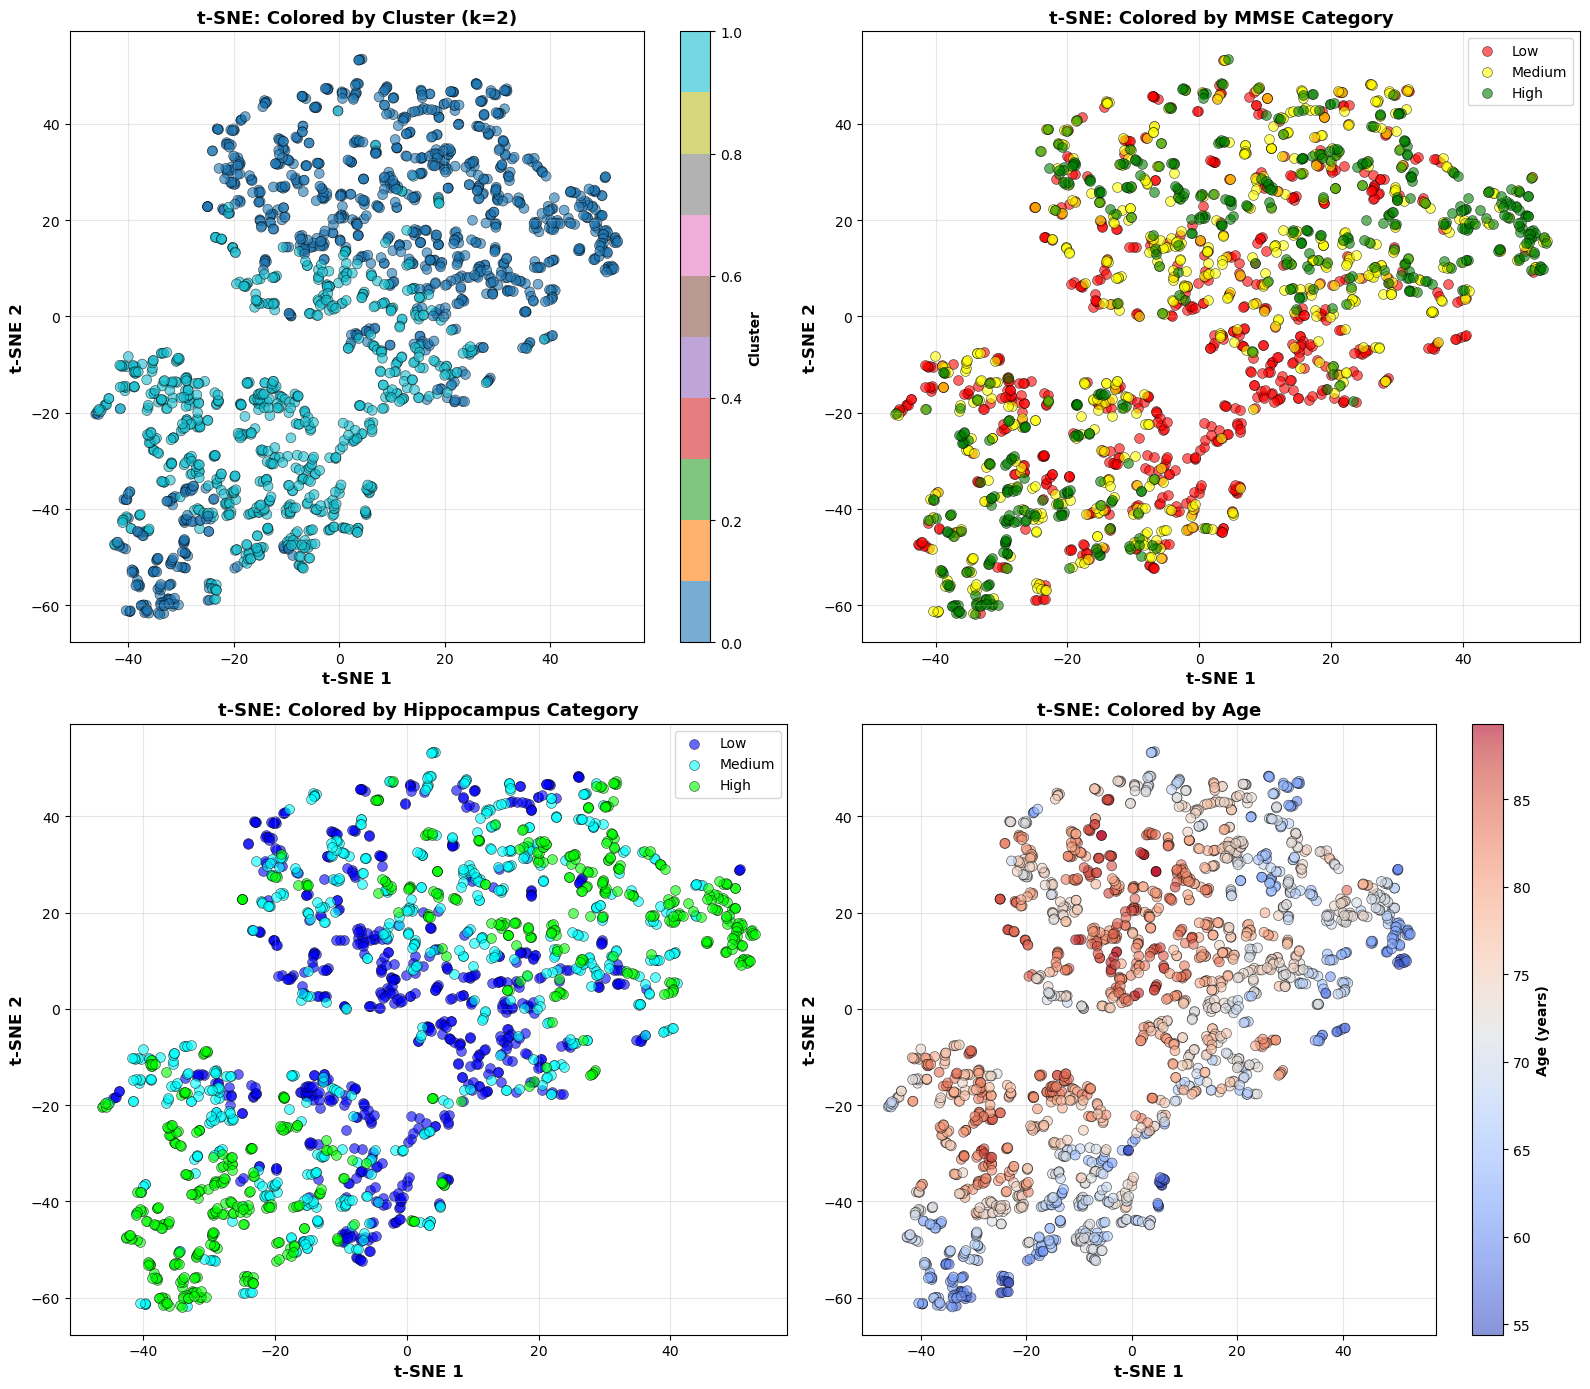


STEP 6: Cluster Characterization

📊 Cluster Characteristics (k=2):

CLUSTER 0 (n=1053)

  Demographics:
    Age:       73.4 ± 7.3 years
    Education: 15.9 ± 3.0 years
    Gender:    901 Male (85.6%), 152 Female (14.4%)

  Cognitive:
    MMSE:  27.17 ± 2.61
    CDRSB: 1.72 ± 1.32

  Brain Measures:
    Hippocampus:  0.4190 ± 0.0778
    WholeBrain:   1047522 ± 85738
    Entorhinal:   3635 ± 702
    MidTemp:      19779 ± 2386
    Ventricles:   47569 ± 24989

CLUSTER 1 (n=759)

  Demographics:
    Age:       75.3 ± 6.9 years
    Education: 15.5 ± 3.0 years
    Gender:    239 Male (31.5%), 520 Female (68.5%)

  Cognitive:
    MMSE:  24.49 ± 4.20
    CDRSB: 3.38 ± 2.73

  Brain Measures:
    Hippocampus:  0.3732 ± 0.0755
    WholeBrain:   902083 ± 76615
    Entorhinal:   2630 ± 622
    MidTemp:      16076 ± 2569
    Ventricles:   45111 ± 21276


STEP 7: Statistical Comparison Between Clusters

📊 ANOVA F-test (comparing 2 clusters):

  AGE                      : F=  31.27, p=0.0000 ***
  PT

In [44]:
# 10. t-SNE Visualization and Cluster Characterization

print("="*80)
print("VISUALIZATION & CLUSTER CHARACTERIZATION")
print("="*80)

# ============================================================================
# t-SNE VISUALIZATION
# ============================================================================
print("\n" + "="*80)
print("STEP 5: t-SNE Visualization")
print("="*80)

# Compute t-SNE
print("\n⏳ Computing t-SNE (this may take a minute)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
mci_tsne = tsne.fit_transform(mci_features_scaled)
print("✓ t-SNE complete!")

# Create visualization dataframe
vis_df = pd.DataFrame({
    'tsne1': mci_tsne[:, 0],
    'tsne2': mci_tsne[:, 1],
    'cluster': best_labels,
    'MMSE_cat': mci_combined_clean['MMSE_cat'].values,
    'Hippo_cat': mci_combined_clean['Hippo_cat'].values,
    'Group_2x2': mci_combined_clean['Group_2x2'].values,
    'AGE': mci_features_clean['AGE'].values,
    'EDUCATION': mci_features_clean['PTEDUCAT'].values,
    'GENDER': mci_features_clean['PTGENDER'].values
})

# ============================================================================
# PLOT 1: t-SNE colored by Cluster
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Plot 1: Clusters
ax1 = axes[0, 0]
scatter = ax1.scatter(vis_df['tsne1'], vis_df['tsne2'], 
                     c=vis_df['cluster'], cmap='tab10', 
                     alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax1.set_xlabel('t-SNE 1', fontweight='bold', fontsize=12)
ax1.set_ylabel('t-SNE 2', fontweight='bold', fontsize=12)
ax1.set_title(f't-SNE: Colored by Cluster (k={best_k})', fontweight='bold', fontsize=13)
cbar1 = plt.colorbar(scatter, ax=ax1)
cbar1.set_label('Cluster', fontweight='bold')
ax1.grid(alpha=0.3)

# Plot 2: MMSE categories
ax2 = axes[0, 1]
mmse_colors = {'Low': 'red', 'Medium': 'yellow', 'High': 'green'}
for cat, color in mmse_colors.items():
    mask = vis_df['MMSE_cat'] == cat
    ax2.scatter(vis_df.loc[mask, 'tsne1'], vis_df.loc[mask, 'tsne2'],
               c=color, label=cat, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax2.set_xlabel('t-SNE 1', fontweight='bold', fontsize=12)
ax2.set_ylabel('t-SNE 2', fontweight='bold', fontsize=12)
ax2.set_title('t-SNE: Colored by MMSE Category', fontweight='bold', fontsize=13)
ax2.legend()
ax2.grid(alpha=0.3)

# Plot 3: Hippocampus categories
ax3 = axes[1, 0]
hippo_colors = {'Low': 'blue', 'Medium': 'cyan', 'High': 'lime'}
for cat, color in hippo_colors.items():
    mask = vis_df['Hippo_cat'] == cat
    ax3.scatter(vis_df.loc[mask, 'tsne1'], vis_df.loc[mask, 'tsne2'],
               c=color, label=cat, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax3.set_xlabel('t-SNE 1', fontweight='bold', fontsize=12)
ax3.set_ylabel('t-SNE 2', fontweight='bold', fontsize=12)
ax3.set_title('t-SNE: Colored by Hippocampus Category', fontweight='bold', fontsize=13)
ax3.legend()
ax3.grid(alpha=0.3)

# Plot 4: Age (continuous)
ax4 = axes[1, 1]
scatter4 = ax4.scatter(vis_df['tsne1'], vis_df['tsne2'],
                      c=vis_df['AGE'], cmap='coolwarm',
                      alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax4.set_xlabel('t-SNE 1', fontweight='bold', fontsize=12)
ax4.set_ylabel('t-SNE 2', fontweight='bold', fontsize=12)
ax4.set_title('t-SNE: Colored by Age', fontweight='bold', fontsize=13)
cbar4 = plt.colorbar(scatter4, ax=ax4)
cbar4.set_label('Age (years)', fontweight='bold')
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# CLUSTER CHARACTERIZATION
# ============================================================================
print("\n" + "="*80)
print("STEP 6: Cluster Characterization")
print("="*80)

# Add cluster labels to features
mci_features_analysis = mci_features_clean.copy()
mci_features_analysis['Cluster'] = best_labels
mci_features_analysis['MMSE'] = df_mci.loc[mci_features_clean.index, 'MMSE']
mci_features_analysis['Hippocampus_normalized'] = df_mci.loc[mci_features_clean.index, 'Hippocampus_normalized']

print(f"\n📊 Cluster Characteristics (k={best_k}):\n")

for cluster_id in range(best_k):
    cluster_data = mci_features_analysis[mci_features_analysis['Cluster'] == cluster_id]
    
    print(f"{'='*70}")
    print(f"CLUSTER {cluster_id} (n={len(cluster_data)})")
    print(f"{'='*70}")
    
    # Demographics
    print(f"\n  Demographics:")
    print(f"    Age:       {cluster_data['AGE'].mean():.1f} ± {cluster_data['AGE'].std():.1f} years")
    print(f"    Education: {cluster_data['PTEDUCAT'].mean():.1f} ± {cluster_data['PTEDUCAT'].std():.1f} years")
    print(f"    Gender:    {cluster_data['PTGENDER'].sum()} Male ({cluster_data['PTGENDER'].mean()*100:.1f}%), "
          f"{len(cluster_data) - cluster_data['PTGENDER'].sum()} Female ({(1-cluster_data['PTGENDER'].mean())*100:.1f}%)")
    
    # Cognitive
    print(f"\n  Cognitive:")
    print(f"    MMSE:  {cluster_data['MMSE'].mean():.2f} ± {cluster_data['MMSE'].std():.2f}")
    print(f"    CDRSB: {cluster_data['CDRSB'].mean():.2f} ± {cluster_data['CDRSB'].std():.2f}")
    
    # Brain measures
    print(f"\n  Brain Measures:")
    print(f"    Hippocampus:  {cluster_data['Hippocampus_normalized'].mean():.4f} ± {cluster_data['Hippocampus_normalized'].std():.4f}")
    print(f"    WholeBrain:   {cluster_data['WholeBrain'].mean():.0f} ± {cluster_data['WholeBrain'].std():.0f}")
    print(f"    Entorhinal:   {cluster_data['Entorhinal'].mean():.0f} ± {cluster_data['Entorhinal'].std():.0f}")
    print(f"    MidTemp:      {cluster_data['MidTemp'].mean():.0f} ± {cluster_data['MidTemp'].std():.0f}")
    print(f"    Ventricles:   {cluster_data['Ventricles'].mean():.0f} ± {cluster_data['Ventricles'].std():.0f}")
    
    print()

# ============================================================================
# STATISTICAL TESTS BETWEEN CLUSTERS
# ============================================================================
print("\n" + "="*80)
print("STEP 7: Statistical Comparison Between Clusters")
print("="*80)

from scipy.stats import f_oneway

test_vars = ['AGE', 'PTEDUCAT', 'WholeBrain', 'Entorhinal', 'MidTemp', 
             'Ventricles', 'CDRSB', 'MMSE', 'Hippocampus_normalized']

print(f"\n📊 ANOVA F-test (comparing {best_k} clusters):\n")

for var in test_vars:
    groups = [mci_features_analysis[mci_features_analysis['Cluster'] == i][var].dropna() 
              for i in range(best_k)]
    
    f_stat, p_val = f_oneway(*groups)
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
    
    print(f"  {var:25s}: F={f_stat:7.2f}, p={p_val:.4f} {sig}")

print("\n" + "="*80)
print("✓ Visualization and characterization complete!")
print("="*80)

In [45]:
df.columns

Index(['New_Path', 'Image Data ID', 'Subject', 'Group-RS:InitialDX', 'Sex',
       'Age', 'Visit', 'Description', 'Acq Date', 'RS:DX_fill', 'DX2', 'RID',
       'COLPROT', 'ORIGPROT', 'PTID', 'SITE', 'VISCODE', 'EXAMDATE', 'DX_bl',
       'AGE', 'PTGENDER', 'PTEDUCAT', 'PTETHCAT', 'PTRACCAT', 'PTMARRY',
       'APOE4', 'CDRSB', 'ADAS11', 'ADAS13', 'ADASQ4', 'MMSE',
       'RAVLT_immediate', 'RAVLT_learning', 'RAVLT_forgetting',
       'RAVLT_perc_forgetting', 'LDELTOTAL', 'DIGITSCOR', 'TRABSCOR', 'FAQ',
       'FLDSTRENG', 'FSVERSION', 'IMAGEUID', 'Ventricles', 'Hippocampus',
       'WholeBrain', 'Entorhinal', 'Fusiform', 'MidTemp', 'ICV', 'DX',
       'mPACCdigit', 'mPACCtrailsB', 'EXAMDATE_bl', 'CDRSB_bl', 'ADAS11_bl',
       'ADAS13_bl', 'ADASQ4_bl', 'MMSE_bl', 'RAVLT_immediate_bl',
       'RAVLT_learning_bl', 'RAVLT_forgetting_bl', 'RAVLT_perc_forgetting_bl',
       'LDELTOTAL_BL', 'DIGITSCOR_bl', 'TRABSCOR_bl', 'FAQ_bl',
       'mPACCdigit_bl', 'mPACCtrailsB_bl', 'FLDSTRENG_bl', '